# Data Preprocessing

## Data Files

[Download](https://epitechfr-my.sharepoint.com/personal/hugo_galan_epitech_eu/_layouts/15/onedrive.aspx?id=%2Fpersonal%2Fhugo%5Fgalan%5Fepitech%5Feu%2FDocuments%2FLoL%2Ddata&ga=1)

## References

- [League of Legends Win Analysis - Medium Article](https://zijiemei.medium.com/league-of-legends-win-analysis-ff6310152430)

- [The Win Probability metric employed by Riot Games - Reddit](https://www.reddit.com/r/leagueoflegends/comments/19e91me/training_machine_learning_models_to_predict/)

## Imports

In [1]:
%pip install pandas scikit-learn matplotlib seaborn numpy

# Imports
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Note: you may need to restart the kernel to use updated packages.


## Load CSV files and create DataFrame

In [2]:
def transform_csv_to_dataframe(folder_path):
    """
    Transforms raw CSV files into a single dataset.

    Params:
        folder_path (str): The path to the folder containing the CSV files.

    Returns:
        (pd.DataFrame): The transformed dataset.
    """
    # Get all CSV files in the folder
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

    # Initialize an empty list to store the dataframes
    dataframes = []

    # Load each CSV file into a dataframe and append it to the list
    for csv_file in csv_files:
        df = pd.read_csv(os.path.join(folder_path, csv_file))
        dataframes.append(df)

    # Concatenate all dataframes into a single dataframe
    combined_df = pd.concat(dataframes, ignore_index=True)

    return combined_df


df_challenger = transform_csv_to_dataframe('challengerleagues/')
df_master = transform_csv_to_dataframe('masterleagues/')
df_grandmaster = transform_csv_to_dataframe('grandmasterleagues/')

In [3]:
df_challenger.head()

,timestamp,soul,1.champion,2.champion,3.champion,4.champion,5.champion,6.champion,7.champion,8.champion,...,RED.ELDER_DRAGON.kills,RED.RIFTHERALD.kills,RED.BARON_NASHOR.kills,RED.HORDE.kills,RED.ATAKHAN.kills,BLUE.TOWER_BUILDING.kills,RED.TOWER_BUILDING.kills,BLUE.INHIBITOR_BUILDING.kills,RED.INHIBITOR_BUILDING.kills,winner
0,0,NaN,799,57,157,81,117,78,106,84,...,0,0,0,0,0,0,0,0,0,BLUE
1,60017,NaN,799,57,157,81,117,78,106,84,...,0,0,0,0,0,0,0,0,0,BLUE
2,120046,NaN,799,57,157,81,117,78,106,84,...,0,0,0,0,0,0,0,0,0,BLUE
3,180116,NaN,799,57,157,81,117,78,106,84,...,0,0,0,0,0,0,0,0,0,BLUE
4,240131,NaN,799,57,157,81,117,78,106,84,...,0,0,0,0,0,0,0,0,0,BLUE


In [4]:
df_challenger.isnull().sum()

timestamp                             0
soul                             302410
1.champion                            0
2.champion                            0
3.champion                            0
                                  ...  
BLUE.TOWER_BUILDING.kills             0
RED.TOWER_BUILDING.kills              0
BLUE.INHIBITOR_BUILDING.kills         0
RED.INHIBITOR_BUILDING.kills          0
winner                                0
Length: 109, dtype: int64

## Winner Feature Encoding

*- BLUE: 0*

*- RED: 1*

In [5]:
# Initialize the label encoder
le = LabelEncoder()

# Fit and transform the 'winner' column
df_challenger['winner'] = le.fit_transform(df_challenger['winner'])
df_master['winner'] = le.fit_transform(df_master['winner'])
df_grandmaster['winner'] = le.fit_transform(df_grandmaster['winner'])

# BLUE: 0, RED: 1
df_challenger[['winner']].head()

,winner
0,0
1,0
2,0
3,0
4,0


## General Features Encoding

In [6]:
print(df_challenger.columns)

Index(['timestamp', 'soul', '1.champion', '2.champion', '3.champion',
       '4.champion', '5.champion', '6.champion', '7.champion', '8.champion',
       ...
       'RED.ELDER_DRAGON.kills', 'RED.RIFTHERALD.kills',
       'RED.BARON_NASHOR.kills', 'RED.HORDE.kills', 'RED.ATAKHAN.kills',
       'BLUE.TOWER_BUILDING.kills', 'RED.TOWER_BUILDING.kills',
       'BLUE.INHIBITOR_BUILDING.kills', 'RED.INHIBITOR_BUILDING.kills',
       'winner'],
      dtype='object', length=109)


In [7]:
df_master.dtypes

timestamp                         int64
soul                             object
1.champion                        int64
2.champion                        int64
3.champion                        int64
                                  ...  
BLUE.TOWER_BUILDING.kills         int64
RED.TOWER_BUILDING.kills          int64
BLUE.INHIBITOR_BUILDING.kills     int64
RED.INHIBITOR_BUILDING.kills      int64
winner                            int64
Length: 109, dtype: object

In [8]:
df_challenger['soul'].unique()

array([nan, 'Mountain', 'Hextech', 'Infernal', 'Ocean', 'Chemtech',
       'Cloud'], dtype=object)

In [9]:
# One-hot encode the 'soul' feature
df_challenger = pd.get_dummies(df_challenger, columns=['soul'], prefix='soul')
df_master = pd.get_dummies(df_master, columns=['soul'], prefix='soul')
df_grandmaster = pd.get_dummies(df_grandmaster, columns=['soul'], prefix='soul')

# Convert boolean columns to integers
boolean_columns = df_challenger.select_dtypes(include='bool').columns
df_challenger[boolean_columns] = df_challenger[boolean_columns].astype(int)

boolean_columns = df_master.select_dtypes(include='bool').columns
df_master[boolean_columns] = df_master[boolean_columns].astype(int)

boolean_columns = df_grandmaster.select_dtypes(include='bool').columns
df_grandmaster[boolean_columns] = df_grandmaster[boolean_columns].astype(int)

# Display the first few rows of the updated dataframe
df_challenger.head()

,timestamp,1.champion,2.champion,3.champion,4.champion,5.champion,6.champion,7.champion,8.champion,9.champion,...,RED.TOWER_BUILDING.kills,BLUE.INHIBITOR_BUILDING.kills,RED.INHIBITOR_BUILDING.kills,winner,soul_Chemtech,soul_Cloud,soul_Hextech,soul_Infernal,soul_Mountain,soul_Ocean
0,0,799,57,157,81,117,78,106,84,110,...,0,0,0,0,0,0,0,0,0,0
1,60017,799,57,157,81,117,78,106,84,110,...,0,0,0,0,0,0,0,0,0,0
2,120046,799,57,157,81,117,78,106,84,110,...,0,0,0,0,0,0,0,0,0,0
3,180116,799,57,157,81,117,78,106,84,110,...,0,0,0,0,0,0,0,0,0,0
4,240131,799,57,157,81,117,78,106,84,110,...,0,0,0,0,0,0,0,0,0,0


## Feature Selection

This is the correlation matrix of the actual features:

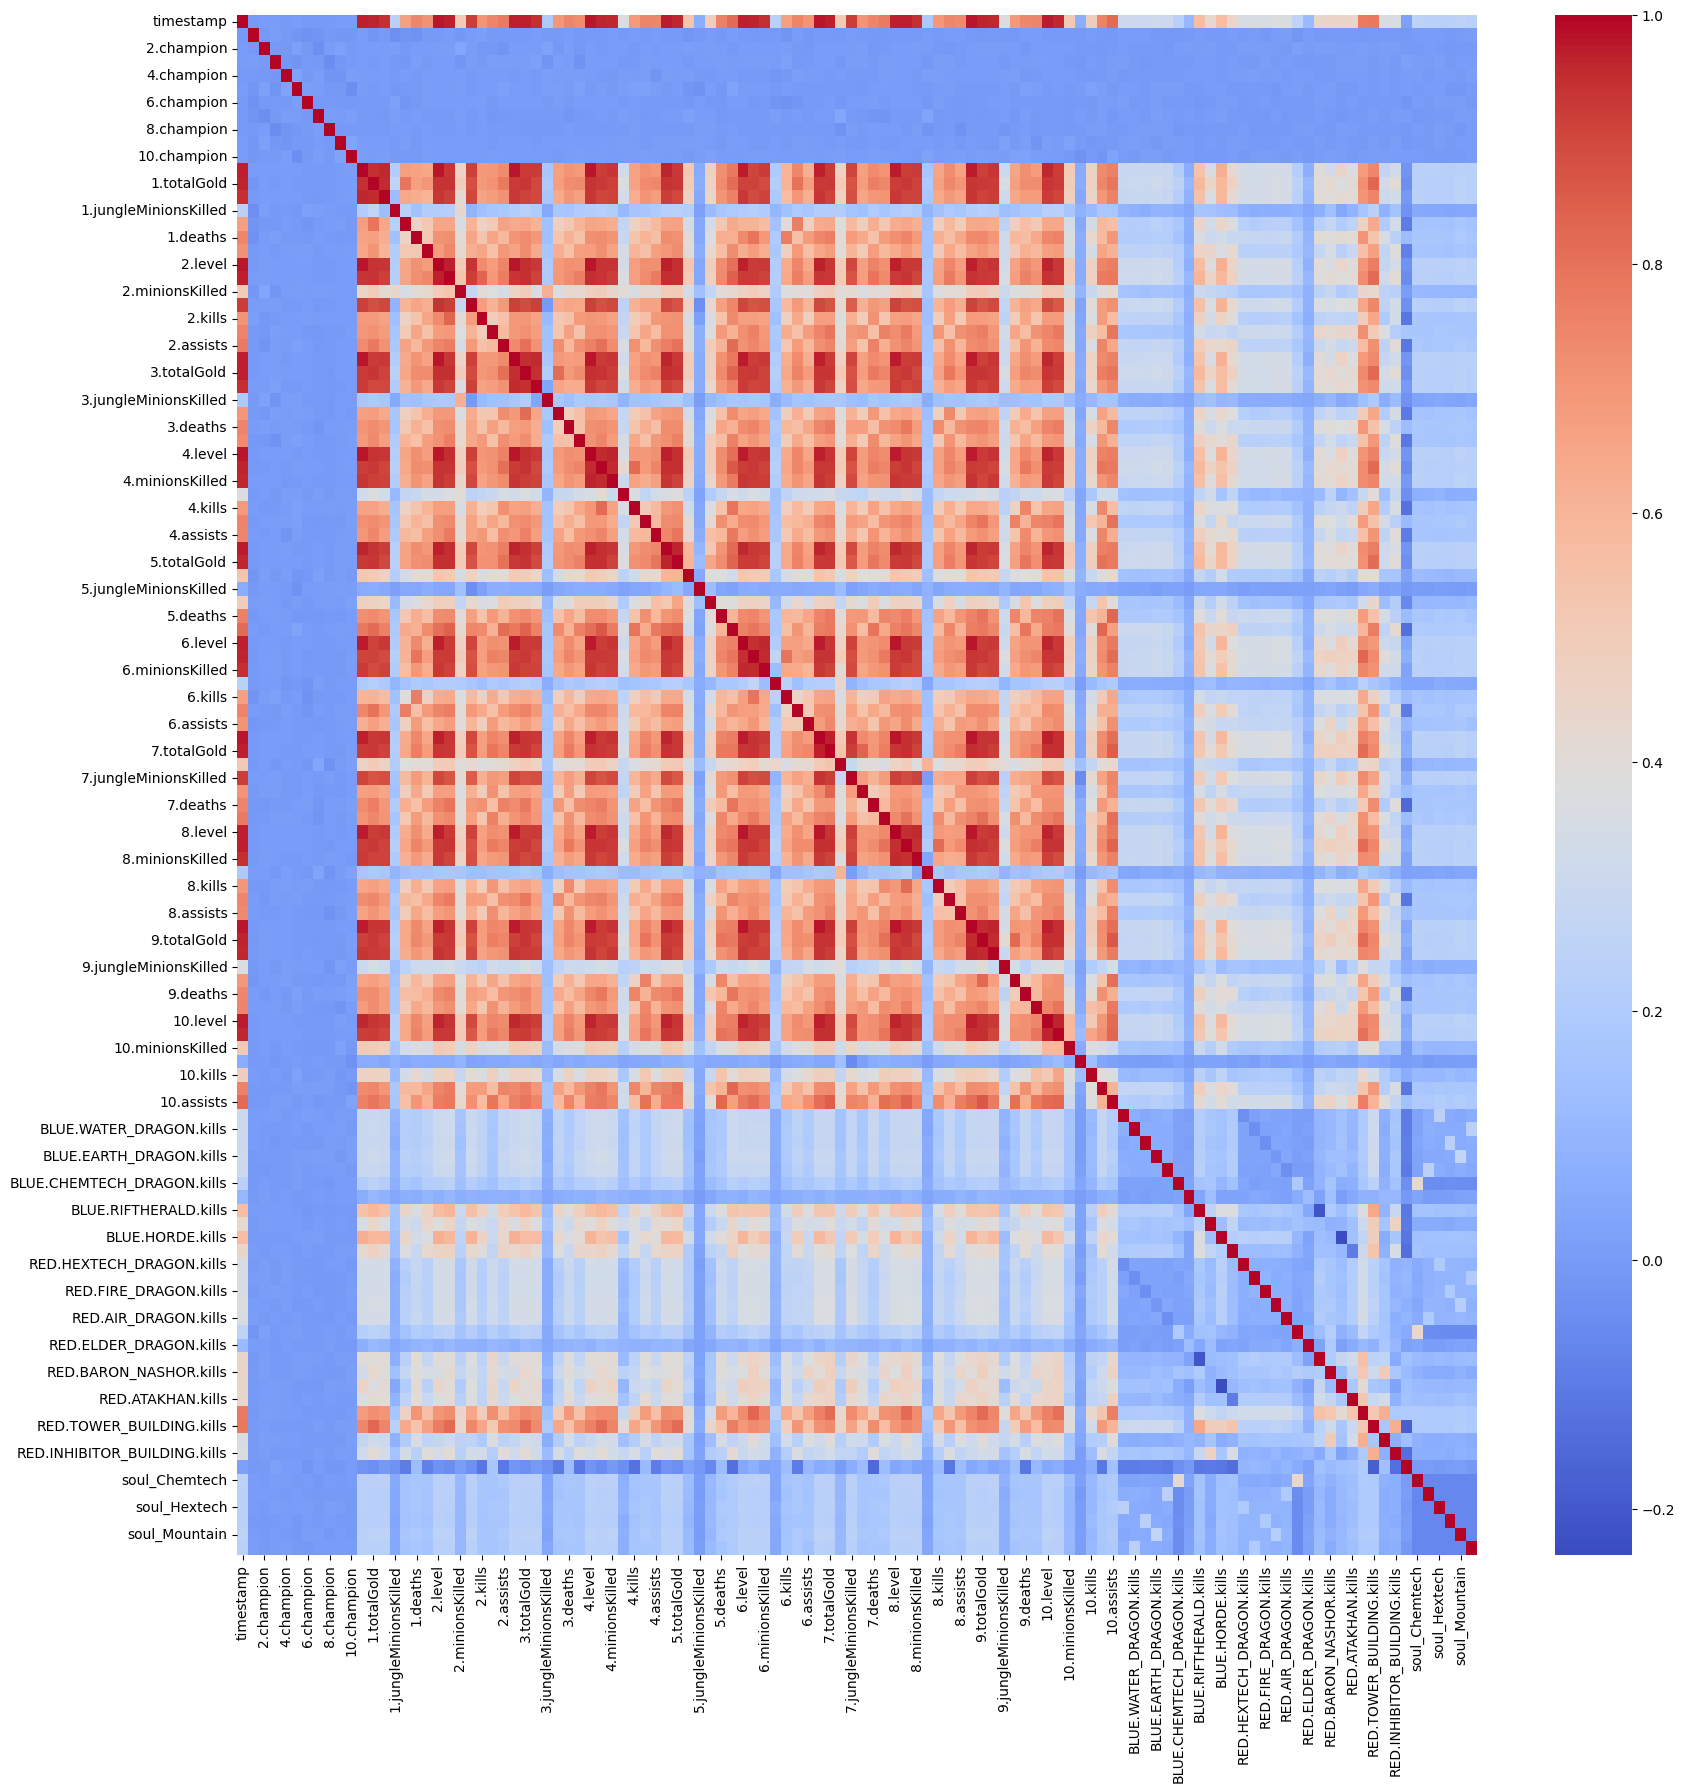

In [10]:
# Calculate the correlation matrix
correlation_matrix = df_challenger.corr()

# Set the size of the plot
plt.figure(figsize=(20, 20))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

### Team features

We will create new features that represent the mean of the features of the two teams. This will allow us to have a more general idea of the game and reduce dimensionality.

In [11]:
# CHALLENGER
# Summation for Blue Team (champions IDs 1..5)
df_challenger['BLUE.level'] = df_challenger[['1.level', '2.level', '3.level', '4.level', '5.level']].sum(axis=1)
df_challenger['BLUE.kills'] = df_challenger[['1.kills', '2.kills', '3.kills', '4.kills', '5.kills']].sum(axis=1)
df_challenger['BLUE.deaths'] = df_challenger[['1.deaths', '2.deaths', '3.deaths', '4.deaths', '5.deaths']].sum(axis=1)
df_challenger['BLUE.assists'] = df_challenger[['1.assists', '2.assists', '3.assists', '4.assists', '5.assists']].sum(axis=1)
df_challenger['BLUE.totalGold'] = df_challenger[['1.totalGold', '2.totalGold', '3.totalGold', '4.totalGold', '5.totalGold']].sum(axis=1)
df_challenger['BLUE.minionsKilled'] = df_challenger[['1.minionsKilled', '2.minionsKilled', '3.minionsKilled', '4.minionsKilled', '5.minionsKilled'
                                                     , '1.jungleMinionsKilled', '2.jungleMinionsKilled', '3.jungleMinionsKilled', '4.jungleMinionsKilled', '5.jungleMinionsKilled']].sum(axis=1)
df_challenger.drop(['1.kills', '2.kills', '3.kills', '4.kills', '5.kills', '1.deaths', '2.deaths', '3.deaths', '4.deaths', '5.deaths', '1.assists', '2.assists', '3.assists', '4.assists', '5.assists',
                     '1.totalGold', '2.totalGold', '3.totalGold', '4.totalGold', '5.totalGold' , '1.minionsKilled', '2.minionsKilled', '3.minionsKilled', '4.minionsKilled', '5.minionsKilled'
                    , '1.jungleMinionsKilled', '2.jungleMinionsKilled', '3.jungleMinionsKilled', '4.jungleMinionsKilled', '5.jungleMinionsKilled'
                    , '1.level', '2.level', '3.level', '4.level', '5.level' ], axis=1, inplace=True)

# Summation for Red Team (champions IDs 6..10)
df_challenger['RED.level'] = df_challenger[['6.level', '7.level', '8.level', '9.level', '10.level']].sum(axis=1)
df_challenger['RED.kills'] = df_challenger[['6.kills', '7.kills', '8.kills', '9.kills', '10.kills']].sum(axis=1)
df_challenger['RED.deaths'] = df_challenger[['6.deaths', '7.deaths', '8.deaths', '9.deaths', '10.deaths']].sum(axis=1)
df_challenger['RED.assists'] = df_challenger[['6.assists', '7.assists', '8.assists', '9.assists', '10.assists']].sum(axis=1)
df_challenger['RED.totalGold'] = df_challenger[['6.totalGold', '7.totalGold', '8.totalGold', '9.totalGold', '10.totalGold']].sum(axis=1)
df_challenger['RED.minionsKilled'] = df_challenger[['6.minionsKilled', '7.minionsKilled', '8.minionsKilled', '9.minionsKilled', '10.minionsKilled'
                                                    , '6.jungleMinionsKilled', '7.jungleMinionsKilled', '8.jungleMinionsKilled', '9.jungleMinionsKilled', '10.jungleMinionsKilled']].sum(axis=1)
df_challenger.drop(['6.kills', '7.kills', '8.kills', '9.kills', '10.kills', '6.deaths', '7.deaths', '8.deaths', '9.deaths', '10.deaths', '6.assists', '7.assists', '8.assists', '9.assists', '10.assists'
                    , '6.totalGold', '7.totalGold', '8.totalGold', '9.totalGold', '10.totalGold', '6.minionsKilled', '7.minionsKilled', '8.minionsKilled', '9.minionsKilled', '10.minionsKilled'
                    , '6.jungleMinionsKilled', '7.jungleMinionsKilled', '8.jungleMinionsKilled', '9.jungleMinionsKilled', '10.jungleMinionsKilled'
                    , '6.level', '7.level', '8.level', '9.level', '10.level' ], axis=1, inplace=True)

# MASTER
# Summation for Blue Team (champions IDs 1..5)
df_master['BLUE.level'] = df_master[['1.level', '2.level', '3.level', '4.level', '5.level']].sum(axis=1)
df_master['BLUE.kills'] = df_master[['1.kills', '2.kills', '3.kills', '4.kills', '5.kills']].sum(axis=1)
df_master['BLUE.deaths'] = df_master[['1.deaths', '2.deaths', '3.deaths', '4.deaths', '5.deaths']].sum(axis=1)
df_master['BLUE.assists'] = df_master[['1.assists', '2.assists', '3.assists', '4.assists', '5.assists']].sum(axis=1)
df_master['BLUE.totalGold'] = df_master[['1.totalGold', '2.totalGold', '3.totalGold', '4.totalGold', '5.totalGold']].sum(axis=1)
df_master['BLUE.minionsKilled'] = df_master[['1.minionsKilled', '2.minionsKilled', '3.minionsKilled', '4.minionsKilled', '5.minionsKilled'
                                                     , '1.jungleMinionsKilled', '2.jungleMinionsKilled', '3.jungleMinionsKilled', '4.jungleMinionsKilled', '5.jungleMinionsKilled']].sum(axis=1)
df_master.drop(['1.kills', '2.kills', '3.kills', '4.kills', '5.kills', '1.deaths', '2.deaths', '3.deaths', '4.deaths', '5.deaths', '1.assists', '2.assists', '3.assists', '4.assists', '5.assists',
                     '1.totalGold', '2.totalGold', '3.totalGold', '4.totalGold', '5.totalGold' , '1.minionsKilled', '2.minionsKilled', '3.minionsKilled', '4.minionsKilled', '5.minionsKilled'
                    , '1.jungleMinionsKilled', '2.jungleMinionsKilled', '3.jungleMinionsKilled', '4.jungleMinionsKilled', '5.jungleMinionsKilled'
                    , '1.level', '2.level', '3.level', '4.level', '5.level' ], axis=1, inplace=True)

# Summation for Red Team (champions IDs 6..10)
df_master['RED.level'] = df_master[['6.level', '7.level', '8.level', '9.level', '10.level']].sum(axis=1)
df_master['RED.kills'] = df_master[['6.kills', '7.kills', '8.kills', '9.kills', '10.kills']].sum(axis=1)
df_master['RED.deaths'] = df_master[['6.deaths', '7.deaths', '8.deaths', '9.deaths', '10.deaths']].sum(axis=1)
df_master['RED.assists'] = df_master[['6.assists', '7.assists', '8.assists', '9.assists', '10.assists']].sum(axis=1)
df_master['RED.totalGold'] = df_master[['6.totalGold', '7.totalGold', '8.totalGold', '9.totalGold', '10.totalGold']].sum(axis=1)
df_master['RED.minionsKilled'] = df_master[['6.minionsKilled', '7.minionsKilled', '8.minionsKilled', '9.minionsKilled', '10.minionsKilled'
                                                    , '6.jungleMinionsKilled', '7.jungleMinionsKilled', '8.jungleMinionsKilled', '9.jungleMinionsKilled', '10.jungleMinionsKilled']].sum(axis=1)
df_master.drop(['6.kills', '7.kills', '8.kills', '9.kills', '10.kills', '6.deaths', '7.deaths', '8.deaths', '9.deaths', '10.deaths', '6.assists', '7.assists', '8.assists', '9.assists', '10.assists'
                    , '6.totalGold', '7.totalGold', '8.totalGold', '9.totalGold', '10.totalGold', '6.minionsKilled', '7.minionsKilled', '8.minionsKilled', '9.minionsKilled', '10.minionsKilled'
                    , '6.jungleMinionsKilled', '7.jungleMinionsKilled', '8.jungleMinionsKilled', '9.jungleMinionsKilled', '10.jungleMinionsKilled'
                    , '6.level', '7.level', '8.level', '9.level', '10.level' ], axis=1, inplace=True)

# GRANDMASTER
# Summation for Blue Team (champions IDs 1..5)
df_grandmaster['BLUE.level'] = df_grandmaster[['1.level', '2.level', '3.level', '4.level', '5.level']].sum(axis=1)
df_grandmaster['BLUE.kills'] = df_grandmaster[['1.kills', '2.kills', '3.kills', '4.kills', '5.kills']].sum(axis=1)
df_grandmaster['BLUE.deaths'] = df_grandmaster[['1.deaths', '2.deaths', '3.deaths', '4.deaths', '5.deaths']].sum(axis=1)
df_grandmaster['BLUE.assists'] = df_grandmaster[['1.assists', '2.assists', '3.assists', '4.assists', '5.assists']].sum(axis=1)
df_grandmaster['BLUE.totalGold'] = df_grandmaster[['1.totalGold', '2.totalGold', '3.totalGold', '4.totalGold', '5.totalGold']].sum(axis=1)
df_grandmaster['BLUE.minionsKilled'] = df_grandmaster[['1.minionsKilled', '2.minionsKilled', '3.minionsKilled', '4.minionsKilled', '5.minionsKilled'
                                                     , '1.jungleMinionsKilled', '2.jungleMinionsKilled', '3.jungleMinionsKilled', '4.jungleMinionsKilled', '5.jungleMinionsKilled']].sum(axis=1)
df_grandmaster.drop(['1.kills', '2.kills', '3.kills', '4.kills', '5.kills', '1.deaths', '2.deaths', '3.deaths', '4.deaths', '5.deaths', '1.assists', '2.assists', '3.assists', '4.assists', '5.assists',
                     '1.totalGold', '2.totalGold', '3.totalGold', '4.totalGold', '5.totalGold' , '1.minionsKilled', '2.minionsKilled', '3.minionsKilled', '4.minionsKilled', '5.minionsKilled'
                    , '1.jungleMinionsKilled', '2.jungleMinionsKilled', '3.jungleMinionsKilled', '4.jungleMinionsKilled', '5.jungleMinionsKilled'
                    , '1.level', '2.level', '3.level', '4.level', '5.level' ], axis=1, inplace=True)

# Summation for Red Team (champions IDs 6..10)
df_grandmaster['RED.level'] = df_grandmaster[['6.level', '7.level', '8.level', '9.level', '10.level']].sum(axis=1)
df_grandmaster['RED.kills'] = df_grandmaster[['6.kills', '7.kills', '8.kills', '9.kills', '10.kills']].sum(axis=1)
df_grandmaster['RED.deaths'] = df_grandmaster[['6.deaths', '7.deaths', '8.deaths', '9.deaths', '10.deaths']].sum(axis=1)
df_grandmaster['RED.assists'] = df_grandmaster[['6.assists', '7.assists', '8.assists', '9.assists', '10.assists']].sum(axis=1)
df_grandmaster['RED.totalGold'] = df_grandmaster[['6.totalGold', '7.totalGold', '8.totalGold', '9.totalGold', '10.totalGold']].sum(axis=1)
df_grandmaster['RED.minionsKilled'] = df_grandmaster[['6.minionsKilled', '7.minionsKilled', '8.minionsKilled', '9.minionsKilled', '10.minionsKilled'
                                                    , '6.jungleMinionsKilled', '7.jungleMinionsKilled', '8.jungleMinionsKilled', '9.jungleMinionsKilled', '10.jungleMinionsKilled']].sum(axis=1)
df_grandmaster.drop(['6.kills', '7.kills', '8.kills', '9.kills', '10.kills', '6.deaths', '7.deaths', '8.deaths', '9.deaths', '10.deaths', '6.assists', '7.assists', '8.assists', '9.assists', '10.assists'
                    , '6.totalGold', '7.totalGold', '8.totalGold', '9.totalGold', '10.totalGold', '6.minionsKilled', '7.minionsKilled', '8.minionsKilled', '9.minionsKilled', '10.minionsKilled'
                    , '6.jungleMinionsKilled', '7.jungleMinionsKilled', '8.jungleMinionsKilled', '9.jungleMinionsKilled', '10.jungleMinionsKilled'
                    , '6.level', '7.level', '8.level', '9.level', '10.level' ], axis=1, inplace=True)

### Drop champion features

Drop these features for the moment. Looking to find a way to encode them or use them in a different way.

In [12]:
df_challenger.drop(['1.champion', '2.champion', '3.champion', '4.champion', '5.champion', '6.champion', '7.champion', '8.champion', '9.champion', '10.champion'], axis=1, inplace=True)
df_master.drop(['1.champion', '2.champion', '3.champion', '4.champion', '5.champion', '6.champion', '7.champion', '8.champion', '9.champion', '10.champion'], axis=1, inplace=True)
df_grandmaster.drop(['1.champion', '2.champion', '3.champion', '4.champion', '5.champion', '6.champion', '7.champion', '8.champion', '9.champion', '10.champion'], axis=1, inplace=True)

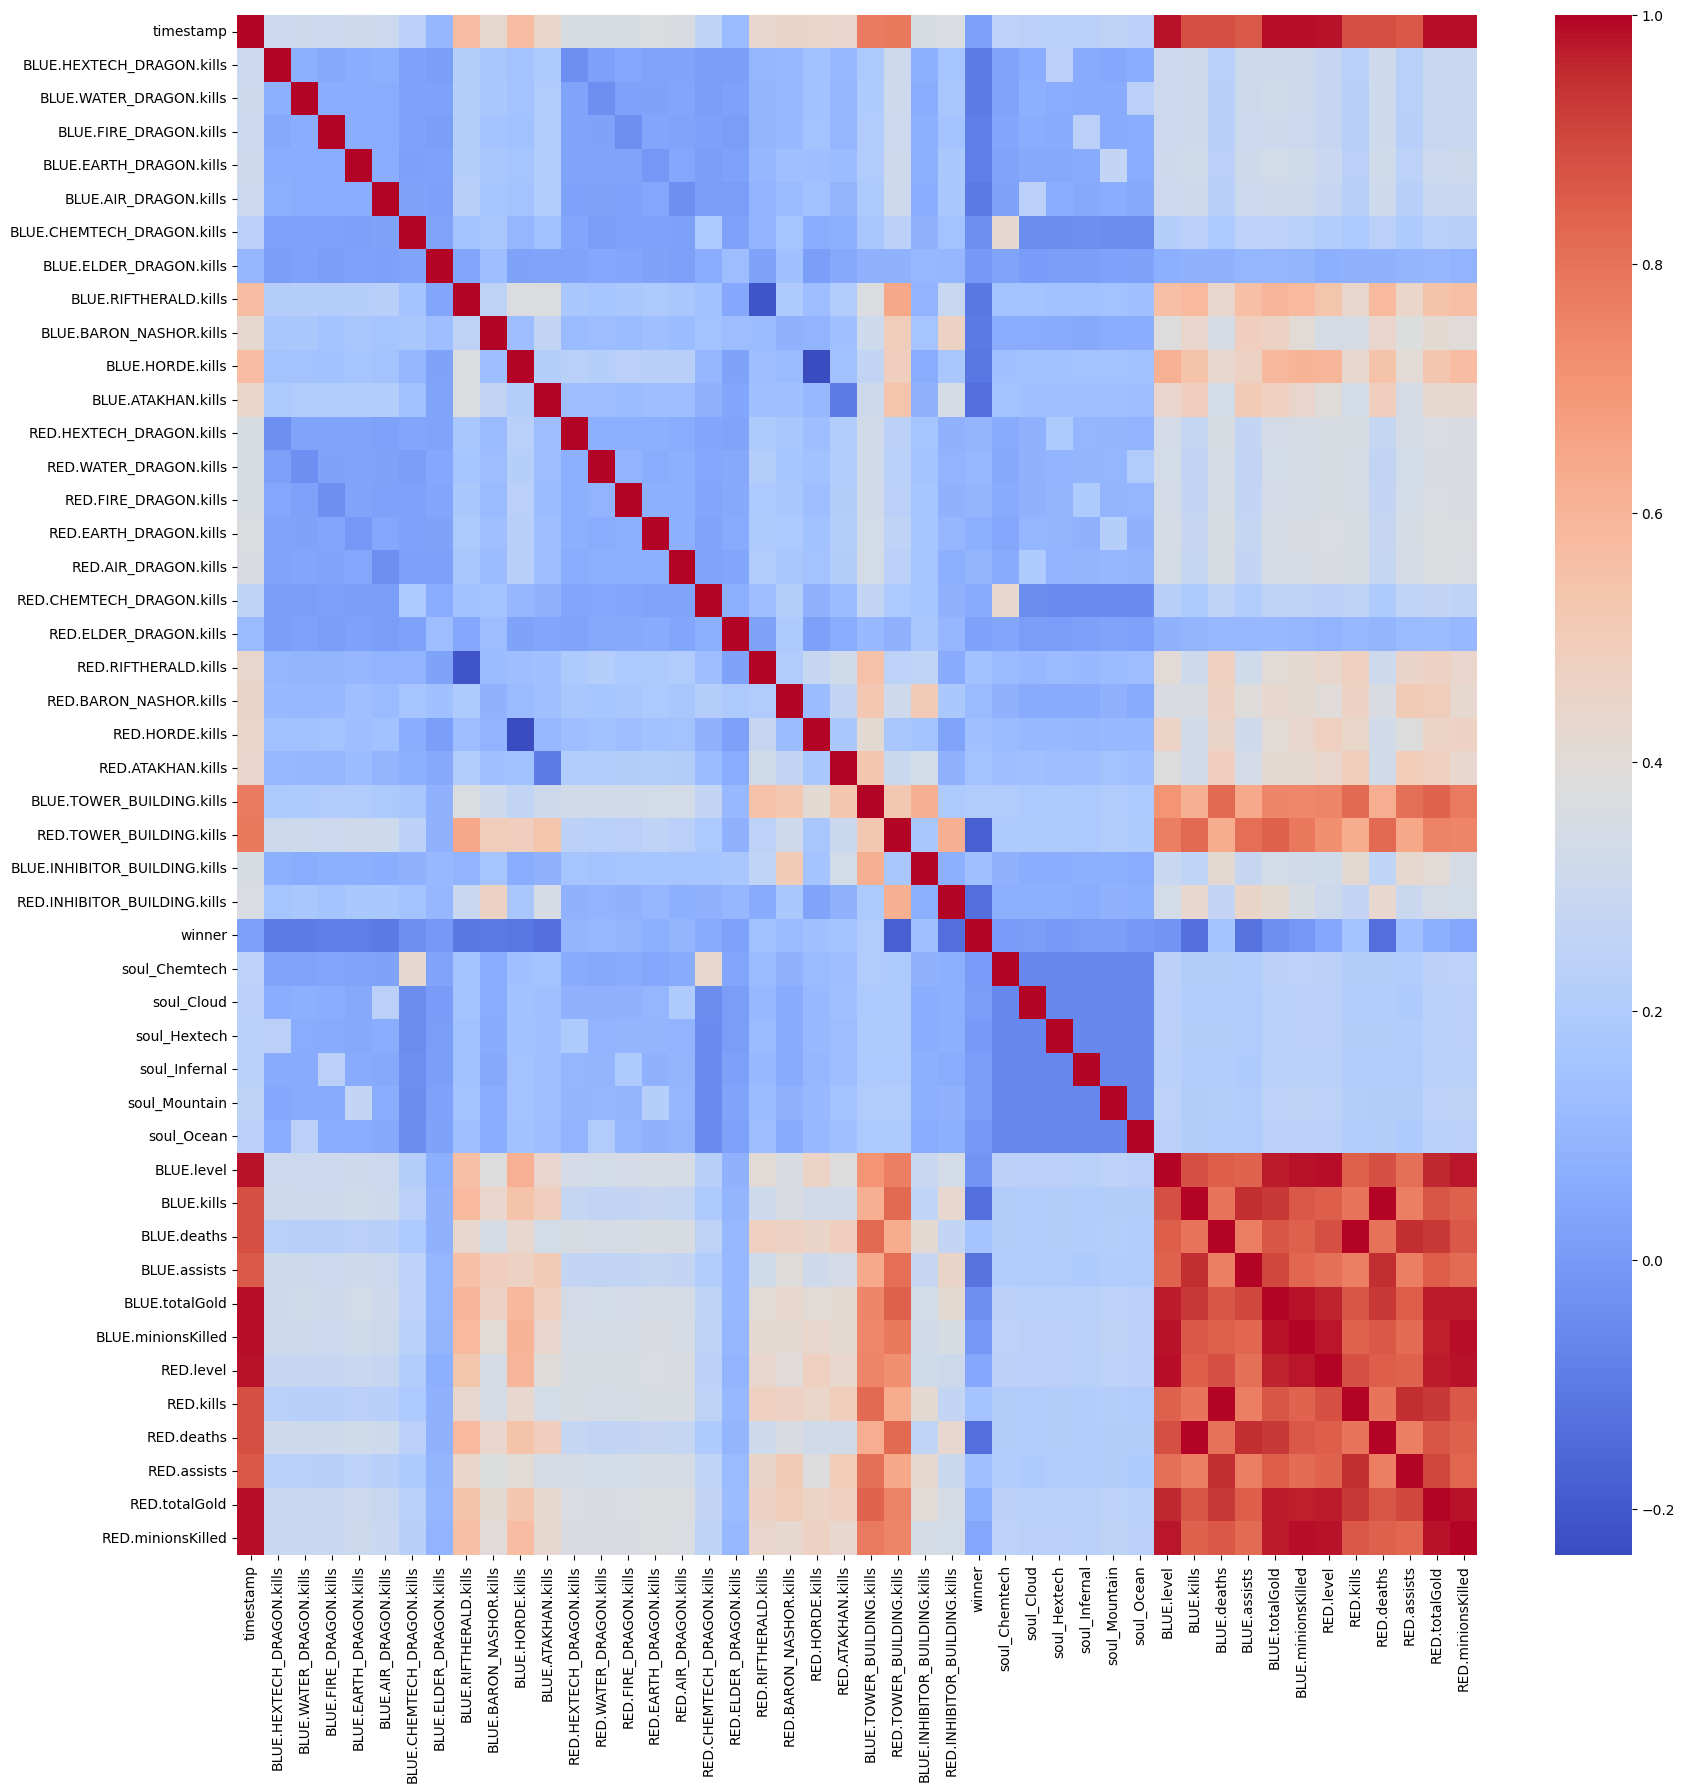

In [13]:
# Calculate the correlation matrix
correlation_matrix = df_challenger.corr()

# Set the size of the plot
plt.figure(figsize=(20, 20))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

### Ratio features

There are strong correlations between the features of the two teams. We will create new 'ratio' features that represent the features of the two teams during time: minionRatio, totalGoldRatio, levelRatio. We create KDA feature to who is a ratio between kills, deaths and assists of each team. And we will drop the original features.

In [14]:
# Minion ratio: minions killed / time

# CHALLENGER
df_challenger['BLUE.minionRatio'] = df_challenger['BLUE.minionsKilled'] / df_challenger['timestamp']
df_challenger['RED.minionRatio'] = df_challenger['RED.minionsKilled'] / df_challenger['timestamp']

df_challenger.drop(['BLUE.minionsKilled', 'RED.minionsKilled'], axis=1, inplace=True)

# MASTER
df_master['BLUE.minionRatio'] = df_master['BLUE.minionsKilled'] / df_master['timestamp']
df_master['RED.minionRatio'] = df_master['RED.minionsKilled'] / df_master['timestamp']

df_master.drop(['BLUE.minionsKilled', 'RED.minionsKilled'], axis=1, inplace=True)

# GRANDMASTER
df_grandmaster['BLUE.minionRatio'] = df_grandmaster['BLUE.minionsKilled'] / df_grandmaster['timestamp']
df_grandmaster['RED.minionRatio'] = df_grandmaster['RED.minionsKilled'] / df_grandmaster['timestamp']

df_grandmaster.drop(['BLUE.minionsKilled', 'RED.minionsKilled'], axis=1, inplace=True)

In [15]:
# Total Gold ratio: totalGold / time

# CHALLENGER
df_challenger['BLUE.totalGoldRatio'] = df_challenger['BLUE.totalGold'] / df_challenger['timestamp']
df_challenger['RED.totalGoldRatio'] = df_challenger['RED.totalGold'] / df_challenger['timestamp']

df_challenger.drop(['BLUE.totalGold', 'RED.totalGold'], axis=1, inplace=True)

# MASTER
df_master['BLUE.totalGoldRatio'] = df_master['BLUE.totalGold'] / df_master['timestamp']
df_master['RED.totalGoldRatio'] = df_master['RED.totalGold'] / df_master['timestamp']

df_master.drop(['BLUE.totalGold', 'RED.totalGold'], axis=1, inplace=True)

# GRANDMASTER
df_grandmaster['BLUE.totalGoldRatio'] = df_grandmaster['BLUE.totalGold'] / df_grandmaster['timestamp']
df_grandmaster['RED.totalGoldRatio'] = df_grandmaster['RED.totalGold'] / df_grandmaster['timestamp']

df_grandmaster.drop(['BLUE.totalGold', 'RED.totalGold'], axis=1, inplace=True)

In [16]:
# Level ratio: level / time

# CHALLENGER
df_challenger['BLUE.levelRatio'] = df_challenger['BLUE.level'] / df_challenger['timestamp']
df_challenger['RED.levelRatio'] = df_challenger['RED.level'] / df_challenger['timestamp']

df_challenger.drop(['BLUE.level', 'RED.level'], axis=1, inplace=True)

# MASTER
df_master['BLUE.levelRatio'] = df_master['BLUE.level'] / df_master['timestamp']
df_master['RED.levelRatio'] = df_master['RED.level'] / df_master['timestamp']

df_master.drop(['BLUE.level', 'RED.level'], axis=1, inplace=True)

# GRANDMASTER
df_grandmaster['BLUE.levelRatio'] = df_grandmaster['BLUE.level'] / df_grandmaster['timestamp']
df_grandmaster['RED.levelRatio'] = df_grandmaster['RED.level'] / df_grandmaster['timestamp']

df_grandmaster.drop(['BLUE.level', 'RED.level'], axis=1, inplace=True)

In [17]:
# KDA ratio: (kills + assists) / deaths

# CHALLENGER
df_challenger['BLUE.kda'] = (df_challenger['BLUE.kills'] + df_challenger['BLUE.assists']) / df_challenger['BLUE.deaths']
df_challenger['RED.kda'] = (df_challenger['RED.kills'] + df_challenger['RED.assists']) / df_challenger['RED.deaths']

df_challenger.drop(['BLUE.kills', 'RED.kills', 'BLUE.deaths', 'RED.deaths', 'BLUE.assists', 'RED.assists'], axis=1, inplace=True)

# MASTER
df_master['BLUE.kda'] = (df_master['BLUE.kills'] + df_master['BLUE.assists']) / df_master['BLUE.deaths']
df_master['RED.kda'] = (df_master['RED.kills'] + df_master['RED.assists']) / df_master['RED.deaths']

df_master.drop(['BLUE.kills', 'RED.kills', 'BLUE.deaths', 'RED.deaths', 'BLUE.assists', 'RED.assists'], axis=1, inplace=True)

# GRANDMASTER
df_grandmaster['BLUE.kda'] = (df_grandmaster['BLUE.kills'] + df_grandmaster['BLUE.assists']) / df_grandmaster['BLUE.deaths']
df_grandmaster['RED.kda'] = (df_grandmaster['RED.kills'] + df_grandmaster['RED.assists']) / df_grandmaster['RED.deaths']

df_grandmaster.drop(['BLUE.kills', 'RED.kills', 'BLUE.deaths', 'RED.deaths', 'BLUE.assists', 'RED.assists'], axis=1, inplace=True)

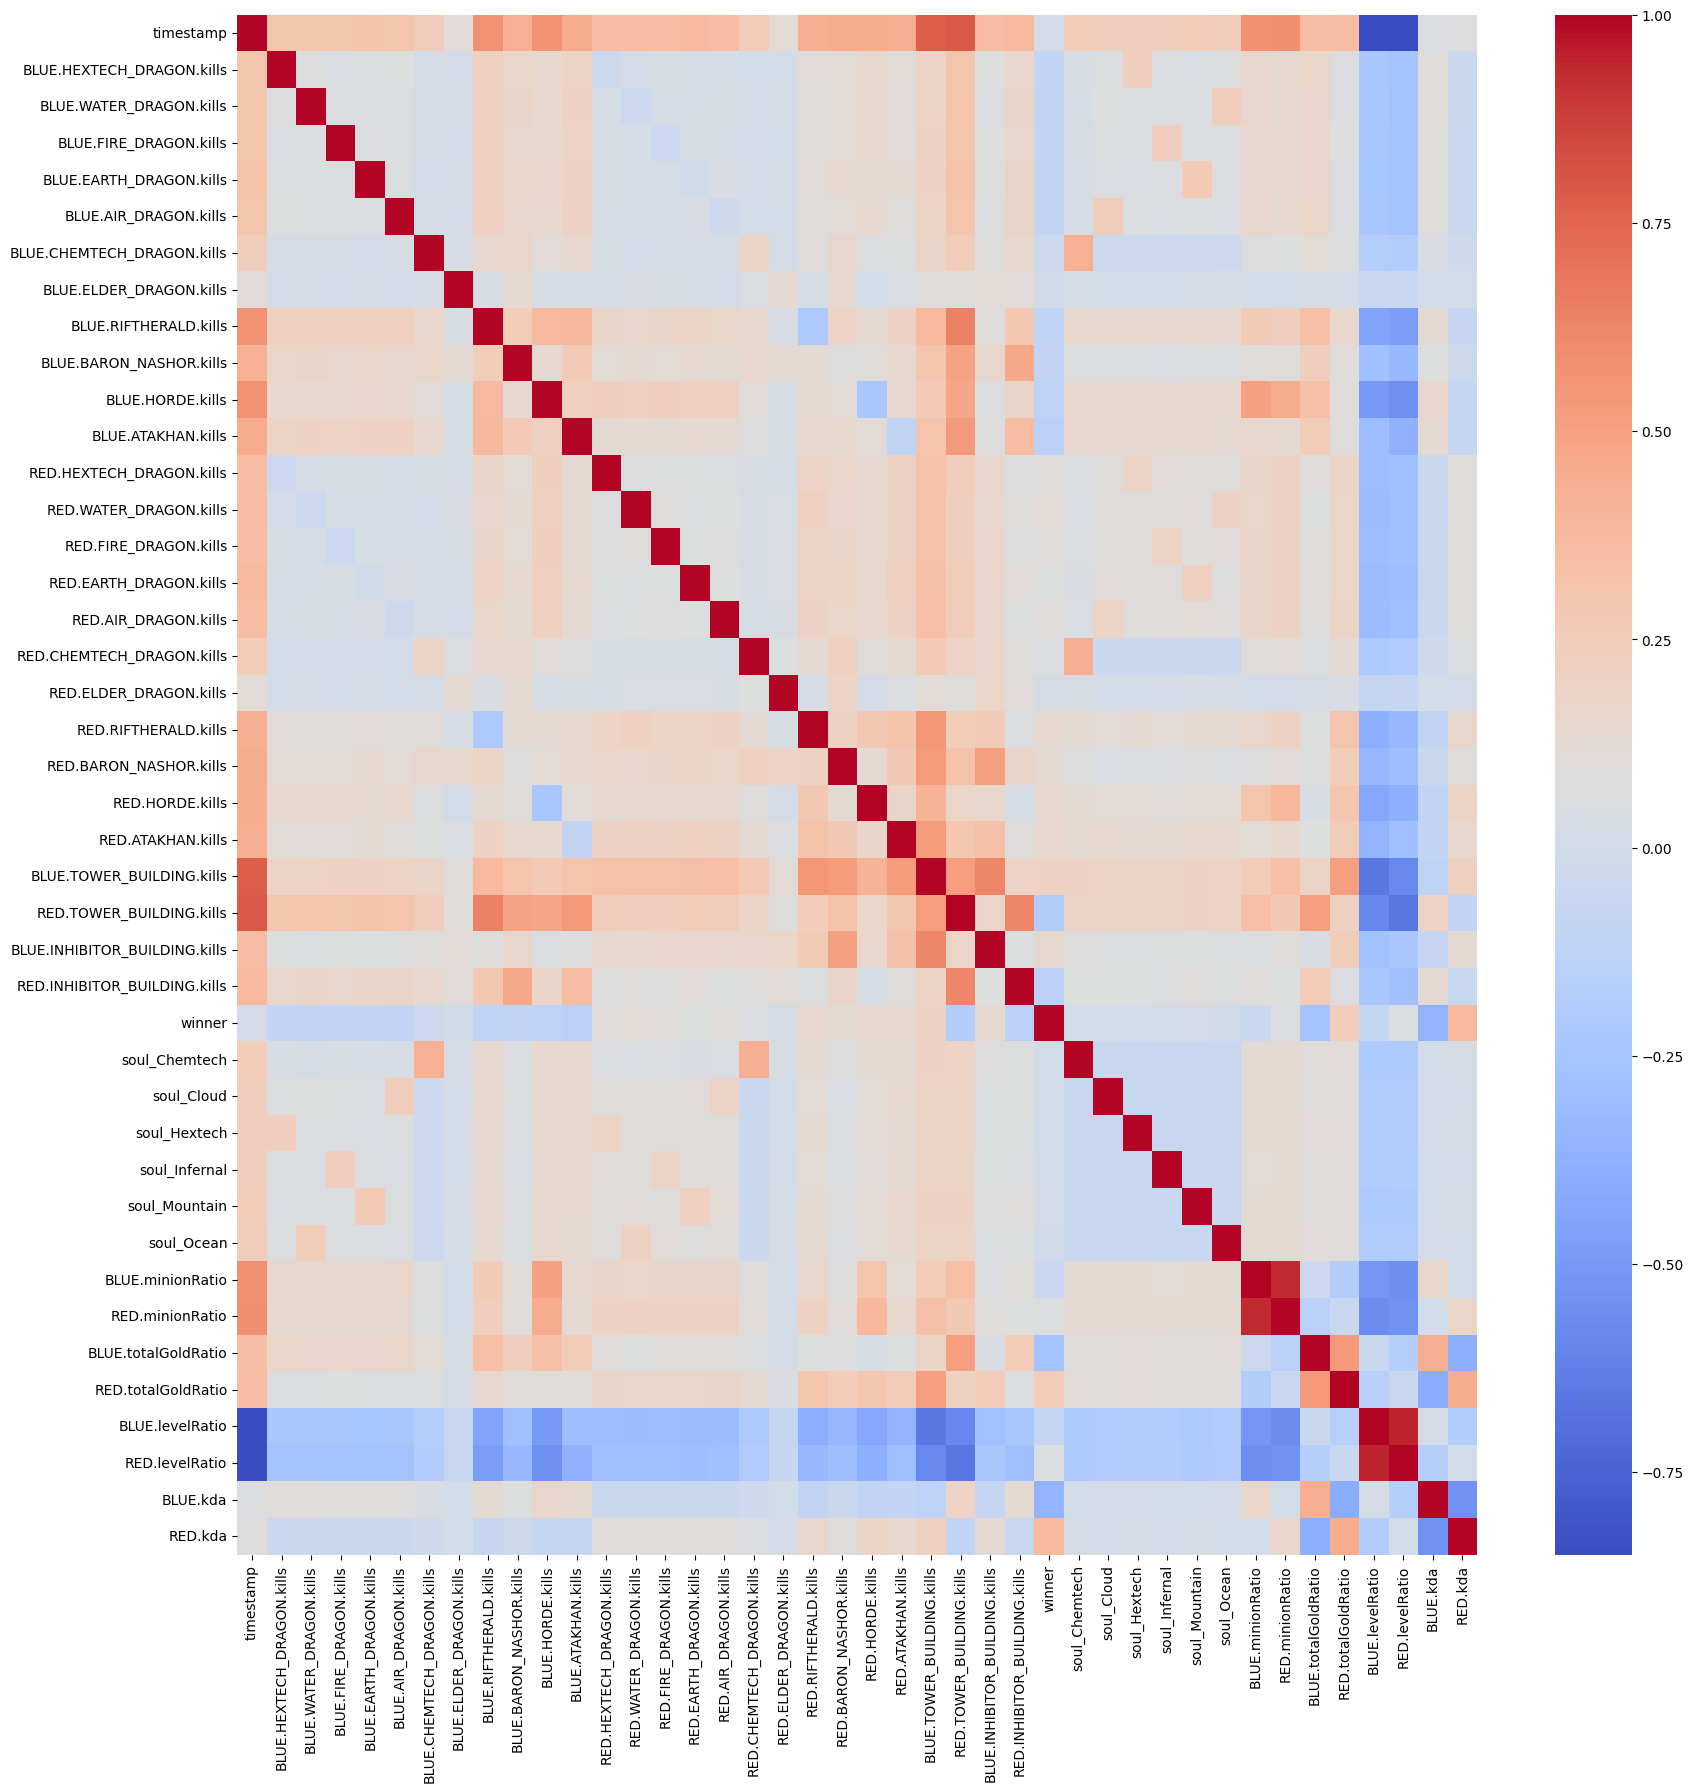

In [18]:
# Calculate the correlation matrix
correlation_matrix = df_challenger.corr()

# Set the size of the plot
plt.figure(figsize=(20, 20))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

### Try a basic model

Now we have two strong correlations with BLUE.levelRatio and RED.levelRatio between timestamp. We will try to create a random forest clasifier to predict the winner of the game to see if we can get a good accuracy and if we keep these features.

Accuracy: 0.77
                     feature  importance
35       BLUE.totalGoldRatio    0.118471
36        RED.totalGoldRatio    0.112802
40                   RED.kda    0.108429
39                  BLUE.kda    0.106760
34           RED.minionRatio    0.077270
33          BLUE.minionRatio    0.076423
37           BLUE.levelRatio    0.069986
38            RED.levelRatio    0.067812
0                  timestamp    0.061205
24  RED.TOWER_BUILDING.kills    0.024246


/var/folders/mr/rqvpsf3j6tl3lgjfgt83f53h0000gn/T/ipykernel_11056/3485921146.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='viridis')


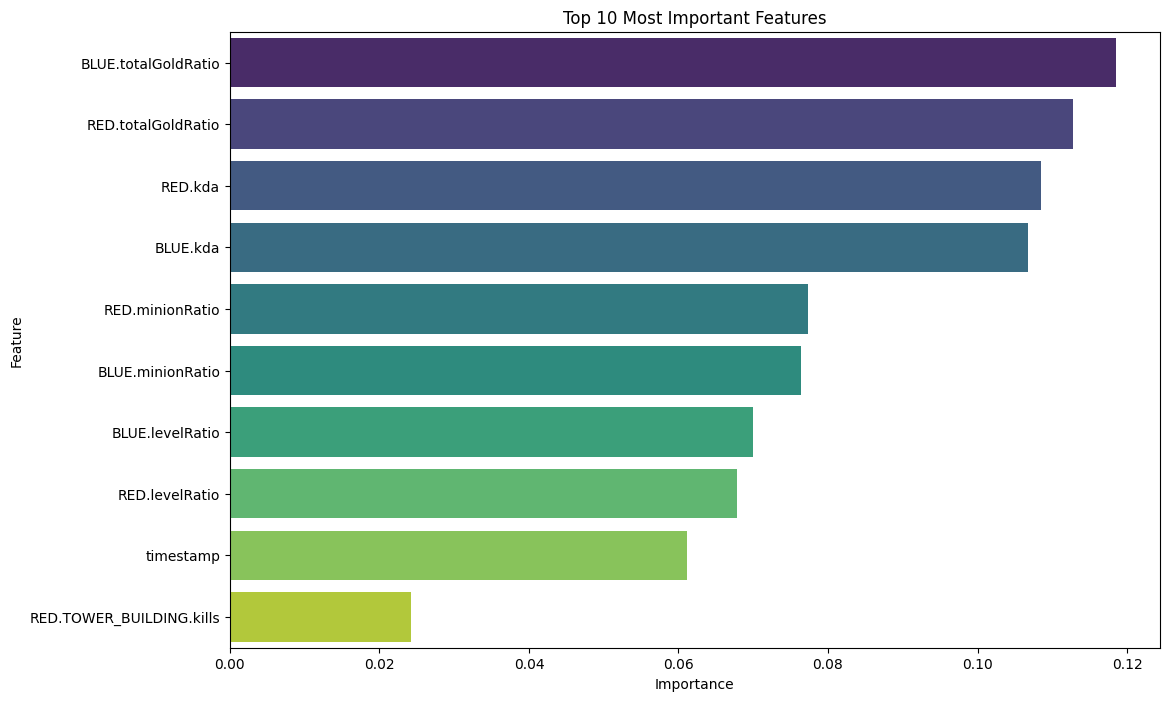

In [19]:
# Split the data into features and target
X = df_challenger.drop('winner', axis=1)
y = df_challenger['winner']

# Replace infinite values with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with the mean of the column
X.fillna(X.mean(), inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the random forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Calculate the feature importances
feature_importances = rf_classifier.feature_importances_

# Create a dataframe to store the feature importances
feature_importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})

# Sort the dataframe by feature importance
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# Display the top 10 most important features
print(feature_importance_df.head(10))

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

BLUE.levelRatio and RED.levelRatio are ine the 10 most important features. So we will keep them.

## Export datasets

In [20]:
# CHALLENGER
df_challenger.to_csv('challenger_dataset.csv', index=False)

# MASTER
df_master.to_csv('master_dataset.csv', index=False)

# GRANDMASTER
df_grandmaster.to_csv('grandmaster_dataset.csv', index=False)

# ALL
df_all = pd.concat([df_challenger, df_master, df_grandmaster], ignore_index=True)
df_all.to_csv('all_dataset.csv', index=False)